# Explore Programming Languages

This notebook explores the programming languages in the AIDev dataset to identify the top 5 most popular languages for our library usage analysis.

We treat JavaScript and TypeScript as a single language for counting purposes.

In [9]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

data_dir = Path("../data")

In [10]:
# Load the repository data
repo_pop_df = pd.read_parquet(data_dir / "repository.parquet")
pr_pop_df = pd.read_parquet(data_dir / "pull_request.parquet")

print(f"Repositories: {len(repo_pop_df):,}")
print(f"Pull Requests: {len(pr_pop_df):,}")

Repositories: 2,807
Pull Requests: 33,596


In [11]:
print(repo_pop_df.columns)

print(pr_pop_df.columns)

Index(['id', 'url', 'license', 'full_name', 'language', 'forks', 'stars'], dtype='object')
Index(['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state',
       'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url',
       'html_url'],
      dtype='object')


## Language Distribution by Repositories

First, let's unify JavaScript and TypeScript for counting purposes.

Top 10 languages by repository count (JS/TS unified):
language_unified
JavaScript/TypeScript    840
Python                   530
Go                       242
C#                       220
Rust                     159
C++                      119
Java                      86
PHP                       69
C                         61
Kotlin                    47
Name: count, dtype: int64


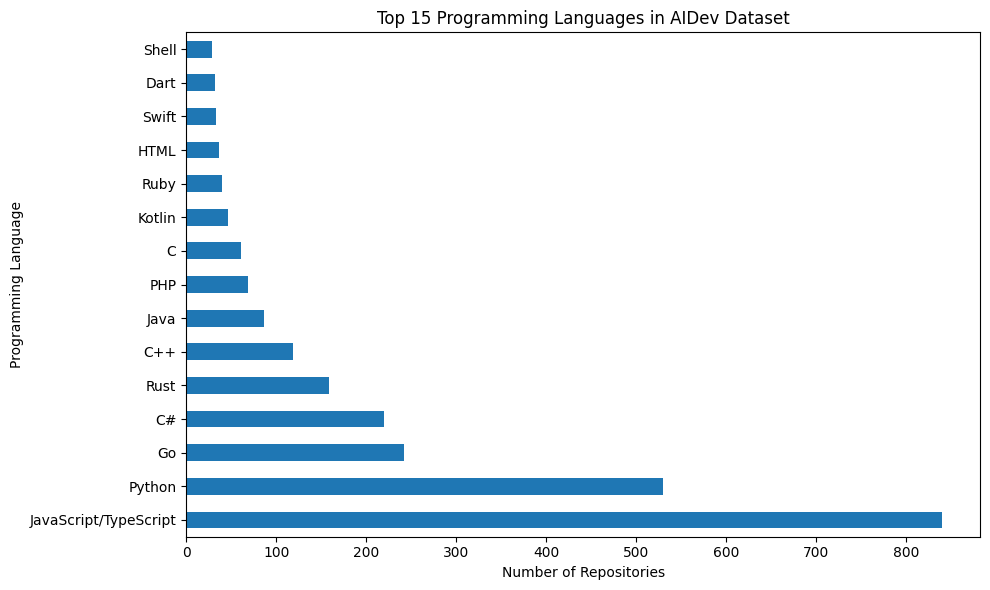

In [12]:
# Create a unified language column (treat JS and TS as one)
repo_pop_df["language_unified"] = repo_pop_df["language"].replace(
    {"JavaScript": "JavaScript/TypeScript", "TypeScript": "JavaScript/TypeScript"}
)

# Count repositories by unified language
lang_counts = repo_pop_df["language_unified"].value_counts()
print("Top 10 languages by repository count (JS/TS unified):")
print(lang_counts.head(10))

# Visualise
fig, ax = plt.subplots(figsize=(10, 6))
lang_counts.head(15).plot(kind="barh", ax=ax)
ax.set_xlabel("Number of Repositories")
ax.set_ylabel("Programming Language")
ax.set_title("Top 15 Programming Languages in AIDev Dataset")
plt.tight_layout()
plt.show()

## Top 5 Languages by Repository Count

Now let's identify the top 5 languages by repository count.

In [13]:
# Get top 5 languages by repository count
top_5_langs_unified = lang_counts.head(5).index.tolist()
print(f"Top 5 languages by repository count: {top_5_langs_unified}")
print()

# Show the counts
for lang in top_5_langs_unified:
    count = lang_counts[lang]
    print(f"{lang}: {count:,} repositories")

Top 5 languages by repository count: ['JavaScript/TypeScript', 'Python', 'Go', 'C#', 'Rust']

JavaScript/TypeScript: 840 repositories
Python: 530 repositories
Go: 242 repositories
C#: 220 repositories
Rust: 159 repositories


## Language Distribution by Pull Requests

In [14]:
# Merge PRs with repo language (original, not unified)
pr_with_lang = pr_pop_df.merge(
    repo_pop_df[["id", "language"]], left_on="repo_id", right_on="id", how="left"
)

# Count PRs by language for top 5 unified languages
print("\nPull requests by language (for top 5):")
for lang_unified in top_5_langs_unified:
    if lang_unified == "JavaScript/TypeScript":
        # Count both JavaScript and TypeScript
        lang_prs = pr_with_lang[
            pr_with_lang["language"].isin(["JavaScript", "TypeScript"])
        ]
    else:
        lang_prs = pr_with_lang[pr_with_lang["language"] == lang_unified]

    print(f"{lang_unified}: {len(lang_prs):,} PRs")


Pull requests by language (for top 5):
JavaScript/TypeScript: 7,490 PRs
Python: 7,191 PRs
Go: 10,108 PRs
C#: 1,985 PRs
Rust: 1,079 PRs


## Agent Distribution by Language

Let's examine how different AI coding agents are distributed across our top 5 languages.

In [15]:
print("\nAgent distribution by language:")
for lang_unified in top_5_langs_unified:
    if lang_unified == "JavaScript/TypeScript":
        # Include both JavaScript and TypeScript
        lang_prs = pr_with_lang[
            pr_with_lang["language"].isin(["JavaScript", "TypeScript"])
        ]
    else:
        lang_prs = pr_with_lang[pr_with_lang["language"] == lang_unified]

    print(f"\n{lang_unified}: {len(lang_prs):,} PRs")
    if "agent" in lang_prs.columns:
        print(lang_prs["agent"].value_counts())


Agent distribution by language:

JavaScript/TypeScript: 7,490 PRs
agent
Devin           2941
OpenAI_Codex    2290
Copilot         1379
Cursor           708
Claude_Code      172
Name: count, dtype: int64

Python: 7,191 PRs
agent
OpenAI_Codex    5209
Devin           1069
Copilot          559
Cursor           254
Claude_Code      100
Name: count, dtype: int64

Go: 10,108 PRs
agent
OpenAI_Codex    9509
Copilot          403
Devin             87
Cursor            71
Claude_Code       38
Name: count, dtype: int64

C#: 1,985 PRs
agent
Copilot         1153
OpenAI_Codex     812
Cursor            10
Devin              9
Claude_Code        1
Name: count, dtype: int64

Rust: 1,079 PRs
agent
OpenAI_Codex    507
Devin           225
Copilot         209
Cursor           98
Claude_Code      40
Name: count, dtype: int64


## Summary Statistics

Let's calculate detailed statistics for our top 5 languages.

In [16]:
print("\n" + "=" * 70)
print("LANGUAGE ANALYSIS SUMMARY")
print("=" * 70)

total_prs = 0
for i, lang_unified in enumerate(top_5_langs_unified, 1):
    if lang_unified == "JavaScript/TypeScript":
        # Count repos for both JS and TS
        lang_repos = repo_pop_df[
            repo_pop_df["language"].isin(["JavaScript", "TypeScript"])
        ]
        lang_prs = pr_with_lang[
            pr_with_lang["language"].isin(["JavaScript", "TypeScript"])
        ]
    else:
        lang_repos = repo_pop_df[repo_pop_df["language"] == lang_unified]
        lang_prs = pr_with_lang[pr_with_lang["language"] == lang_unified]

    total_prs += len(lang_prs)

    print(f"\n{i}. {lang_unified}")
    print(f"   Repositories: {len(lang_repos):,}")
    print(f"   Pull Requests: {len(lang_prs):,}")
    if len(lang_repos) > 0:
        print(f"   Avg PRs per repo: {len(lang_prs) / len(lang_repos):.1f}")

print(f"\nTotal PRs in top 5 languages: {total_prs:,}")
print(f"Percentage of all PRs: {100 * total_prs / len(pr_pop_df):.1f}%")


LANGUAGE ANALYSIS SUMMARY

1. JavaScript/TypeScript
   Repositories: 840
   Pull Requests: 7,490
   Avg PRs per repo: 8.9

2. Python
   Repositories: 530
   Pull Requests: 7,191
   Avg PRs per repo: 13.6

3. Go
   Repositories: 242
   Pull Requests: 10,108
   Avg PRs per repo: 41.8

4. C#
   Repositories: 220
   Pull Requests: 1,985
   Avg PRs per repo: 9.0

5. Rust
   Repositories: 159
   Pull Requests: 1,079
   Avg PRs per repo: 6.8

Total PRs in top 5 languages: 27,853
Percentage of all PRs: 82.9%


## Save Filtered Data

Save the pull requests for our top 5 languages for further analysis.

In [18]:
# Create a list of actual languages (expanding JS/TS)
actual_languages = []
for lang_unified in top_5_langs_unified:
    if lang_unified == "JavaScript/TypeScript":
        actual_languages.extend(["JavaScript", "TypeScript"])
    else:
        actual_languages.append(lang_unified)

print(f"Languages to include: {actual_languages}")

# Filter PRs to top 5 languages
top_lang_prs = pr_with_lang[pr_with_lang["language"].isin(actual_languages)].copy()

# Add language_analysis column (JavaScript -> TypeScript, everything lowercase)
top_lang_prs["language_analysis"] = (
    top_lang_prs["language"].replace({"JavaScript": "TypeScript"}).str.lower()
)

print("\nLanguage mapping:")
for orig_lang in sorted(top_lang_prs["language"].unique()):
    analysis_lang = top_lang_prs[top_lang_prs["language"] == orig_lang][
        "language_analysis"
    ].iloc[0]
    print(f"  {orig_lang} -> {analysis_lang}")

# Save the filtered data
output_path = data_dir / "top5_languages_prs.parquet"
top_lang_prs.to_parquet(output_path, index=False)
print(f"\nSaved {len(top_lang_prs):,} PRs to: {output_path}")
print(f"Original languages: {sorted(top_lang_prs['language'].unique())}")
print(f"Analysis languages: {sorted(top_lang_prs['language_analysis'].unique())}")

Languages to include: ['JavaScript', 'TypeScript', 'Python', 'Go', 'C#', 'Rust']

Language mapping:
  C# -> c#
  Go -> go
  JavaScript -> typescript
  Python -> python
  Rust -> rust
  TypeScript -> typescript

Saved 27,853 PRs to: ../data/top5_languages_prs.parquet
Original languages: ['C#', 'Go', 'JavaScript', 'Python', 'Rust', 'TypeScript']
Analysis languages: ['c#', 'go', 'python', 'rust', 'typescript']
